In [11]:
import numpy as np
import pandas as pd

# 加载 .npz 文件
data = np.load('../singleset/p3ht_ttns_64.npz',allow_pickle=True)

# 'mol list', 'tempearture', 'total time', 'other info', 'r square array', 
# 'electron occupations array', 'phonon occupations array', 'k occupations array', 
# 'eph entropy', 'bond entropy', 'coherent length array', 'time series'
df = data['e_occupations']

df = pd.DataFrame(df)
print(df)
df.to_excel('p3ht_64_strictkrylov.xlsx', index=False)

           0             1             2             3             4   \
0    1.000000  4.985629e-20  1.692524e-21  6.102174e-23  2.412780e-24   
1    0.889750  2.185339e-02  1.285627e-04  3.328174e-07  5.216158e-10   
2    0.616631  7.415042e-02  1.850230e-03  1.970073e-05  1.165659e-07   
3    0.316354  1.266565e-01  7.855146e-03  1.971423e-04  2.685904e-06   
4    0.118785  1.530645e-01  1.942844e-02  9.248026e-04  2.326034e-05   
..        ...           ...           ...           ...           ...   
196  0.086663  5.781635e-03  5.348130e-03  7.647322e-03  1.176352e-02   
197  0.085767  6.089199e-03  5.344324e-03  7.589845e-03  1.169043e-02   
198  0.084617  6.535908e-03  5.312862e-03  7.576314e-03  1.166836e-02   
199  0.083098  6.928085e-03  5.294339e-03  7.585388e-03  1.168849e-02   
200  0.081243  7.138481e-03  5.334854e-03  7.597147e-03  1.173711e-02   

               5             6             7             8             9   \
0    9.206044e-26  2.939389e-27  7.094480e-29 

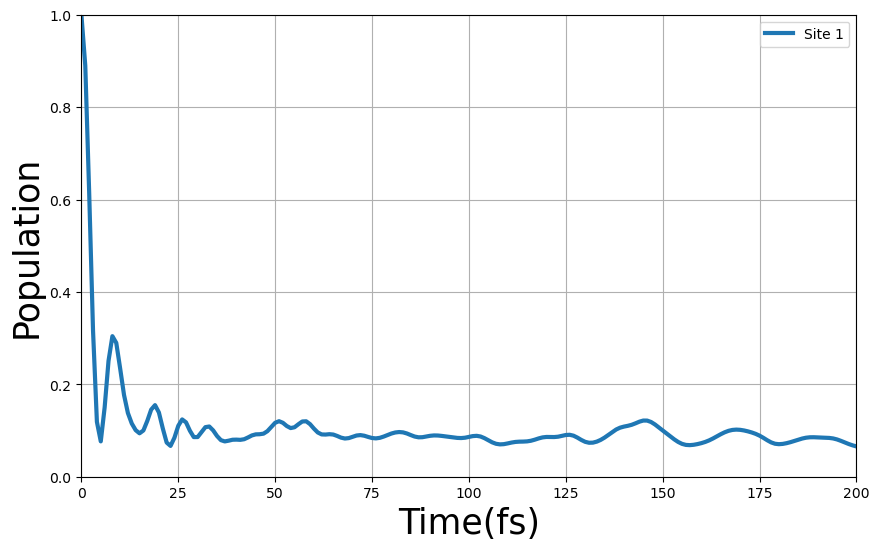

In [5]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

excel_path = Path('p3ht_32_strictkrylov.xlsx')

if not excel_path.exists():
    print(f'Skip: {excel_path} does not exist')
else:
    # 读取Excel文件
    df = pd.read_excel(excel_path)
    # df = pd.read_excel('../../fmo_benchmark.xlsx')

    # 提取数据
    x = np.arange(0,df.shape[0],1)
    x = x * 1 

    y_columns = df.iloc[:, 0:1]  # 第1-7列作为y坐标

    # 创建图表
    plt.figure(figsize=(10, 6))

    # 绘制七条线
    for i in range(0,y_columns.shape[1]):
        plt.plot(x, y_columns.iloc[:, i],label=f'Site {i+1}',linewidth=3)

    # 添加图表元素
    plt.xlabel('Time(fs)',size = 25)
    plt.ylabel('Population',size = 25)
    plt.xlim((0, 200))
    plt.ylim((0, 1))
    plt.title('')
    plt.legend()
    plt.grid(True)

    # 显示图表
    plt.show()

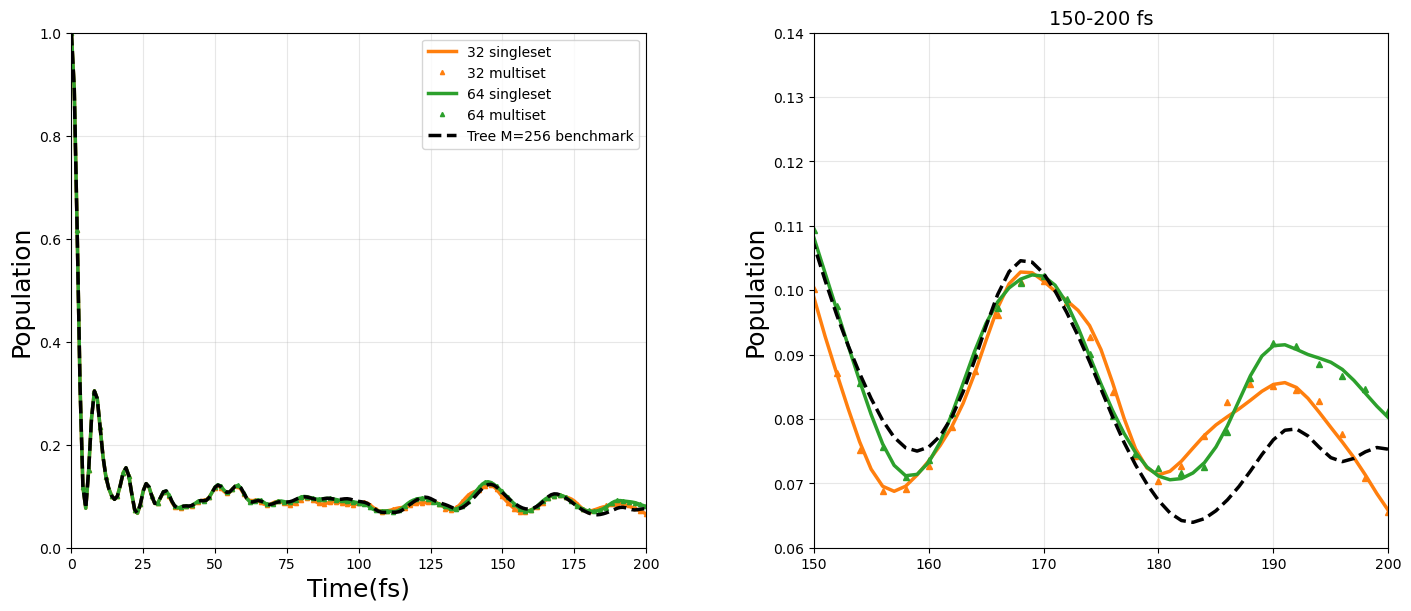

In [12]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

datasets = [
    # ('16', 'p3ht_16_multiset.xlsx', 'p3ht_16_singleset.xlsx'),
    ('32', 'p3ht_32_strictkrylov.xlsx', 'p3ht_32_singleset.xlsx'),
    ('64', 'p3ht_64_strictkrylov.xlsx', 'p3ht_64_singleset.xlsx'),
    # ('128', 'p3ht_128_multiset.xlsx', 'p3ht_128_singleset.xlsx'),
]

colors = {'16': 'tab:blue', '32': 'tab:orange', '64': 'tab:green', '128': 'tab:red'}
zoom_start, zoom_end = 150, 200
zoom_values = []
plotted = False

fig, (ax, ax_zoom) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    constrained_layout=True,
    gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.12},
)

for size, multiset_file, singleset_file in datasets:
    multiset_path = Path(multiset_file)
    singleset_path = Path(singleset_file)
    color = colors[size]

    if singleset_path.exists():
        df_single = pd.read_excel(singleset_path)
        x_single = np.arange(df_single.shape[0])
        y_single = df_single.iloc[:, 0:1].iloc[:, 0]
        zoom_values.extend(y_single[(x_single >= zoom_start) & (x_single <= zoom_end)].tolist())

        ax.plot(x_single, y_single, color=color, linewidth=2.5, label=f'{size} singleset')
        ax_zoom.plot(x_single, y_single, color=color, linewidth=2.5)
        plotted = True
    else:
        print(f'Skip {size} singleset: missing {singleset_path}')

    if multiset_path.exists():
        df_multi = pd.read_excel(multiset_path)
        x_multi = np.arange(df_multi.shape[0])
        y_multi = df_multi.iloc[:, 0:1].iloc[:, 0]
        zoom_values.extend(y_multi[(x_multi >= zoom_start) & (x_multi <= zoom_end)].tolist())

        ax.plot(
            x_multi,
            y_multi,
            color=color,
            linestyle='None',
            marker='^',
            markersize=3,
            markevery=2,
            label=f'{size} multiset',
        )
        ax_zoom.plot(
            x_multi,
            y_multi,
            color=color,
            linestyle='None',
            marker='^',
            markersize=5,
            markevery=2,
        )
        plotted = True
    else:
        print(f'Skip {size} multiset: missing {multiset_path}')


benchmark_path = Path("../2026Further_plot/figures/Tree5.npz")
if not benchmark_path.exists():
    benchmark_path = Path("../../../multiset_ttn/P3HT:PCBM/2026Further_plot/figures/Tree5.npz")

if benchmark_path.exists():
    try:
        benchmark_npz = np.load(benchmark_path)
        benchmark_idx = benchmark_npz["M"].astype(str).tolist().index("256")
        y_benchmark = benchmark_npz["n"][benchmark_idx, 0]
        x_benchmark = np.arange(len(y_benchmark))
        zoom_values.extend(y_benchmark[(x_benchmark >= zoom_start) & (x_benchmark <= zoom_end)].tolist())

        ax.plot(
            x_benchmark,
            y_benchmark,
            color="black",
            linestyle="--",
            linewidth=2.5,
            label="Tree M=256 benchmark",
        )
        ax_zoom.plot(
            x_benchmark,
            y_benchmark,
            color="black",
            linestyle="--",
            linewidth=2.5,
        )
        plotted = True
    except (KeyError, ValueError, IndexError) as exc:
        print(f"Skip Tree M=256 benchmark: invalid {benchmark_path}: {exc}")
else:
    print(f"Skip Tree M=256 benchmark: missing {benchmark_path}")

if not plotted:
    plt.close(fig)
    print('Skip plot: no dataset files found')
else:
    ax.set_xlabel('Time(fs)', size=18)
    ax.set_ylabel('Population', size=18)
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax_zoom.set_xlim(zoom_start, zoom_end)
    if zoom_values:
        zoom_min = min(zoom_values)
        zoom_max = max(zoom_values)
        zoom_margin = max((zoom_max - zoom_min) * 0.1, 1e-4)
        ax_zoom.set_ylim(zoom_min - zoom_margin, zoom_max + zoom_margin)
    ax_zoom.set_ylim(0.06, 0.14)
    ax_zoom.set_ylabel('Population', size=18)
    ax_zoom.set_title('150-200 fs', size=14)
    ax_zoom.grid(True, alpha=0.3)

    plt.show()


default krylov (χ = 32): max ACE=3.7999e-03, mean ACE=1.8145e-03
strict krylov (χ = 32): max ACE=3.8874e-03, mean ACE=1.8322e-03
default krylov (χ = 64): max ACE=2.4815e-03, mean ACE=7.3872e-04
strict krylov (χ = 64): max ACE=2.5058e-03, mean ACE=7.4082e-04


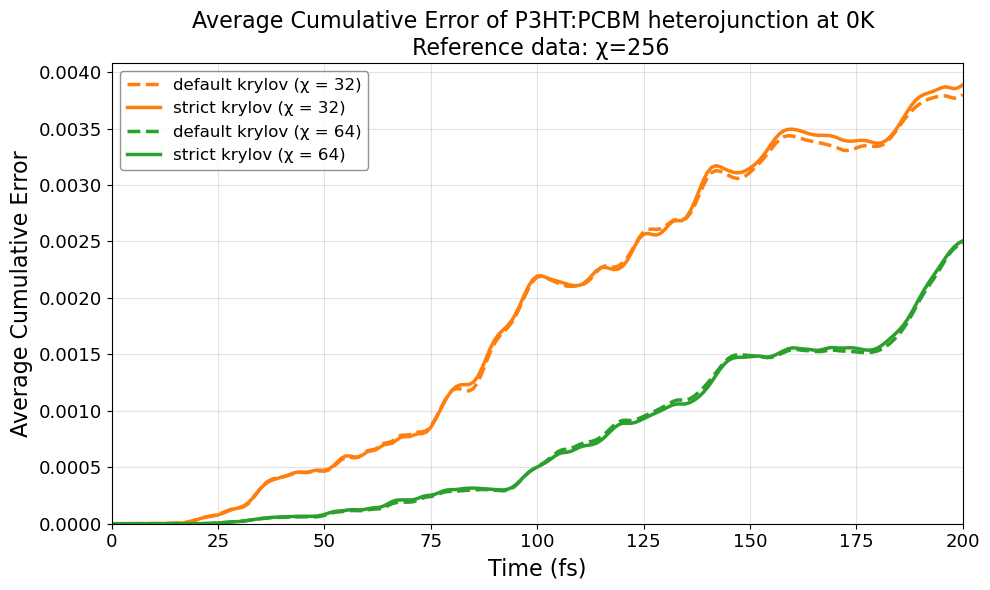

In [17]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

benchmark_path = Path("../../../multiset_ttn/P3HT:PCBM/2026Further_plot/figures/Tree5.npz")
if not benchmark_path.exists():
    benchmark_path = Path("multiset_ttn/P3HT:PCBM/2026Further_plot/figures/Tree5.npz")

data_files = [
    ("default krylov (χ = 32)", Path("p3ht_32_singleset.xlsx"), "tab:orange", "--"),
    ("strict krylov (χ = 32)", Path("p3ht_32_strictkrylov.xlsx"), "tab:orange", "-"),
    ("default krylov (χ = 64)", Path("p3ht_64_singleset.xlsx"), "tab:green", "--"),
    ("strict krylov (χ = 64)", Path("p3ht_64_strictkrylov.xlsx"), "tab:green", "-"),
]

dt_fs = 1.0


def cumulative_error(y, y_ref, x, x_ref):
    y_ref_interp = np.interp(x, x_ref, y_ref)
    abs_err = np.abs(y - y_ref_interp)
    err = np.zeros(len(x), dtype=float)
    if len(x) > 1:
        seg_integral = 0.5 * (abs_err[1:] + abs_err[:-1]) * np.diff(x)
        err[1:] = np.cumsum(seg_integral) / x[1:]
    return err


if not benchmark_path.exists():
    print(f"Skip cumulative error plot: missing {benchmark_path}")
else:
    benchmark_npz = np.load(benchmark_path)
    benchmark_idx = benchmark_npz["M"].astype(str).tolist().index("256")
    y_ref = benchmark_npz["n"][benchmark_idx, 0].astype(float)
    x_ref = np.arange(len(y_ref)) * dt_fs

    fig, ax = plt.subplots(figsize=(10, 6))
    plotted = False
    # ax.plot(x_ref, np.zeros_like(x_ref), color="black", linestyle="--", linewidth=2.5, label="TTN chi=256 benchmark")

    for label, path, color, linestyle in data_files:
        if not path.exists():
            print(f"Skip {label}: missing {path}")
            continue

        y = pd.read_excel(path).iloc[:, 0].to_numpy(dtype=float)
        x = np.arange(len(y)) * dt_fs
        err = cumulative_error(y, y_ref, x, x_ref)
        ax.plot(x, err, label=label, color=color, linestyle=linestyle, linewidth=2.5)
        plotted = True
        print(f"{label}: max ACE={err.max():.4e}, mean ACE={err.mean():.4e}")

    if not plotted:
        plt.close(fig)
        print("Skip cumulative error plot: no data files found")
    else:
        ax.set_xlabel("Time (fs)", fontsize=16)
        ax.set_ylabel("Average Cumulative Error", fontsize=16)
        ax.set_title("Average Cumulative Error of P3HT:PCBM heterojunction at 0K \n Reference data: χ=256", fontsize=16)
        ax.set_xlim(0, 200)
        ax.set_ylim(bottom=0)
        ax.tick_params(labelsize=13)
        ax.legend(fontsize=12, framealpha=0.85, edgecolor="gray")
        ax.grid(True, alpha=0.35)
        plt.tight_layout()
        plt.savefig("P3HT_avg_cumulative_error_vs_ttn_chi256.png", dpi=150)
        plt.show()
